# 🌐 Notebook 04: Router–Worker SOC Triage with Manual Orchestration

A ransomware outbreak is unfolding across endpoint, identity, and network telemetry. In this notebook, we implement a **Router-Worker multi-agent pattern** using the Azure AI Foundry SDK (`azure-ai-projects` 2.0 + Responses API).

Instead of legacy linked-agent tooling, the orchestration is done manually in Python:
1. Dispatch the incident to four specialist agents
2. Run each specialist through a function-call loop
3. Collect specialist findings
4. Pass findings to a router agent that synthesizes a single incident report

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
import nest_asyncio; nest_asyncio.apply()
from soc_workshop.settings import get_settings
from soc_workshop.clients import get_project_client, configure_tracing
from soc_workshop.incident_schema import Alert, InvestigationRecord
from soc_workshop.tools.sentinel_mock import get_alert_details, get_related_alerts, get_sign_in_logs, get_entity_risk
from soc_workshop.tools.kql_mock import run_kql_query
from soc_workshop.tools.search_mock import search_threat_intel, search_playbooks
from azure.ai.projects.models import PromptAgentDefinition, FunctionTool
from openai.types.responses.response_input_param import FunctionCallOutput
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import asdict
import re
from IPython.display import Markdown, display

settings = get_settings()
configure_tracing()
project_client = get_project_client(settings)
openai_client = project_client.get_openai_client()
print(f"Model deployment: {settings.model_deployment}")

Model deployment: gpt-4.1


## Building the Specialist Team

We define strict JSON-schema tools and create **versioned specialist agents** with `project_client.agents.create_version(...)`.

In [2]:
kql_tool = FunctionTool(
    name="run_kql_query",
    description="Execute a KQL query against the SOC Log Analytics workspace.",
    parameters={
        "type": "object",
        "properties": {"query": {"type": "string", "description": "KQL query string"}},
        "required": ["query"],
        "additionalProperties": False,
    },
    strict=True,
)

signin_tool = FunctionTool(
    name="get_sign_in_logs",
    description="Retrieve recent sign-in activity for a user principal name.",
    parameters={
        "type": "object",
        "properties": {"user_principal": {"type": "string", "description": "User principal name"}},
        "required": ["user_principal"],
        "additionalProperties": False,
    },
    strict=True,
)

entity_risk_tool = FunctionTool(
    name="get_entity_risk",
    description="Look up the risk score for an entity.",
    parameters={
        "type": "object",
        "properties": {
            "entity_type": {"type": "string", "description": "Entity type: user, ip, host, hash"},
            "entity_value": {"type": "string", "description": "Entity value to look up"}
        },
        "required": ["entity_type", "entity_value"],
        "additionalProperties": False,
    },
    strict=True,
)

search_ti_tool = FunctionTool(
    name="search_threat_intel",
    description="Search the threat intelligence knowledge base.",
    parameters={
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query"},
            "top_k": {"type": "integer", "description": "Number of results"}
        },
        "required": ["query", "top_k"],
        "additionalProperties": False,
    },
    strict=True,
)

search_pb_tool = FunctionTool(
    name="search_playbooks",
    description="Search SOC response playbooks.",
    parameters={
        "type": "object",
        "properties": {
            "query": {"type": "string", "description": "Search query"},
            "top_k": {"type": "integer", "description": "Number of results"}
        },
        "required": ["query", "top_k"],
        "additionalProperties": False,
    },
    strict=True,
)

In [3]:
host_agent = project_client.agents.create_version(
    agent_name="host-endpoint-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a Host/Endpoint Analyst in a SOC. Investigate process execution, persistence, "
            "ransomware staging behavior, and endpoint blast radius using KQL. Focus on MITRE ATT&CK mapping."
        ),
        tools=[kql_tool],
    ),
)

identity_agent = project_client.agents.create_version(
    agent_name="identity-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are an Identity Analyst in a SOC. Investigate account compromise, risky sign-ins, "
            "MFA bypass indicators, and privilege abuse."
        ),
        tools=[signin_tool, entity_risk_tool],
    ),
)

network_agent = project_client.agents.create_version(
    agent_name="network-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a Network Analyst in a SOC. Investigate C2 traffic, lateral movement, and "
            "possible exfiltration over suspicious outbound channels."
        ),
        tools=[kql_tool, entity_risk_tool],
    ),
)

ti_agent = project_client.agents.create_version(
    agent_name="threat-intel-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a Threat Intel Analyst in a SOC. Correlate observed behavior and indicators with "
            "known campaigns, tooling, and response playbooks."
        ),
        tools=[search_ti_tool, search_pb_tool],
    ),
)

In [4]:
agents_df = pd.DataFrame([
    {"name": host_agent.name, "version": host_agent.version, "role": "Host Analyst", "tools": "run_kql_query"},
    {"name": identity_agent.name, "version": identity_agent.version, "role": "Identity Analyst", "tools": "get_sign_in_logs, get_entity_risk"},
    {"name": network_agent.name, "version": network_agent.version, "role": "Network Analyst", "tools": "run_kql_query, get_entity_risk"},
    {"name": ti_agent.name, "version": ti_agent.version, "role": "Threat Intel Analyst", "tools": "search_threat_intel, search_playbooks"},
])
display(agents_df)

,name,version,role,tools
0,host-endpoint-analyst,1,Host Analyst,run_kql_query
1,identity-analyst,1,Identity Analyst,"get_sign_in_logs, get_entity_risk"
2,network-analyst,1,Network Analyst,"run_kql_query, get_entity_risk"
3,threat-intel-analyst,1,Threat Intel Analyst,"search_threat_intel, search_playbooks"


## The Router: Incident Commander

The router has **no tools**. It receives specialist findings as context and synthesizes a unified report.

This manual orchestration replaces the old Threads/Runs linked-agent pattern.

In [5]:
router_agent = project_client.agents.create_version(
    agent_name="soc-triage-router",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are the SOC Triage Router and Incident Commander. You do not call tools directly. "
            "Given specialist analyses, produce a unified report with exact sections: "
            "## Executive Summary, ## Attack Timeline, ## Affected Scope, ## IOCs, "
            "## Confidence Score, ## Recommended Actions. Keep findings evidence-based and concise."
        ),
        tools=[],
    ),
)
print(f"Created router: {router_agent.name} v{router_agent.version}")

Created router: soc-triage-router v1


## Launch Investigation

Load the six-alert ransomware chain, dispatch each specialist with domain prompts, then gather outputs for router synthesis.

In [6]:
def run_agent_with_tools(openai_client, agent, user_input, tool_dispatch, max_rounds=10):
    response = openai_client.responses.create(
        input=user_input,
        model=settings.model_deployment,
        extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
    )
    tool_call_log = []
    for _ in range(max_rounds):
        fn_calls = [item for item in response.output if item.type == "function_call"]
        if not fn_calls:
            break
        fn_outputs = []
        for call in fn_calls:
            fn = tool_dispatch.get(call.name)
            if fn is None:
                result = json.dumps({"error": f"Unknown: {call.name}"})
            else:
                args = json.loads(call.arguments)
                result = fn(**args)
            tool_call_log.append({"tool": call.name, "args": call.arguments, "result_len": len(result)})
            fn_outputs.append(FunctionCallOutput(type="function_call_output", call_id=call.call_id, output=result))
        response = openai_client.responses.create(
            input=fn_outputs,
            previous_response_id=response.id,
            extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
        )
    return response, tool_call_log

In [7]:
with open("../data/alerts.json", "r", encoding="utf-8") as f:
    alerts_raw = json.load(f)

alerts = [Alert.from_dict(item.copy()) for item in alerts_raw]
selected_alerts = alerts[:6]

briefing_payload = json.dumps([asdict(a) for a in selected_alerts], indent=2)
incident_briefing = (
    "Ransomware attack-chain triage request. Correlate full progression from initial access to encryption impact and exfiltration. "
    "Prioritize confidence-backed findings and concrete response actions.\n\n"
    f"Alerts (6 total):\n```json\n{briefing_payload}\n```"
)

host_prompt = incident_briefing + "\n\nDomain focus: Endpoint process/file telemetry. Validate staging, execution, privilege escalation, and encryption behavior."
identity_prompt = incident_briefing + "\n\nDomain focus: Identity compromise. Validate suspicious sign-ins, account takeover, and risk scoring for impacted users/identities."
network_prompt = incident_briefing + "\n\nDomain focus: Network behavior. Validate C2, lateral movement, suspicious destinations, and potential data exfiltration channels."
ti_prompt = incident_briefing + "\n\nDomain focus: Threat intel and response guidance. Map observed IOCs/TTPs to known campaigns and relevant SOC playbooks."

In [8]:
specialists = [
    (
        "host-endpoint-analyst",
        host_agent,
        host_prompt,
        {"run_kql_query": run_kql_query},
    ),
    (
        "identity-analyst",
        identity_agent,
        identity_prompt,
        {"get_sign_in_logs": get_sign_in_logs, "get_entity_risk": get_entity_risk},
    ),
    (
        "network-analyst",
        network_agent,
        network_prompt,
        {"run_kql_query": run_kql_query, "get_entity_risk": get_entity_risk},
    ),
    (
        "threat-intel-analyst",
        ti_agent,
        ti_prompt,
        {"search_threat_intel": search_threat_intel, "search_playbooks": search_playbooks},
    ),
]

specialist_results = {}
tool_call_logs = {}

for name, agent, dispatch_prompt, dispatch in specialists:
    response, call_log = run_agent_with_tools(openai_client, agent, dispatch_prompt, dispatch)
    specialist_results[name] = response.output_text
    tool_call_logs[name] = call_log

router_context = "## Specialist Findings\n\n"
for name, text in specialist_results.items():
    router_context += f"### {name}\n{text}\n\n"

router_prompt = (
    "Synthesize these specialist analyses into a unified incident report for SOC leadership. "
    "Preserve chronology and explain confidence.\n\n"
    + router_context
)

router_response = openai_client.responses.create(
    input=router_prompt,
    model=settings.model_deployment,
    extra_body={"agent_reference": {"name": router_agent.name, "type": "agent_reference"}},
)

display(Markdown(router_response.output_text))

## Executive Summary

On March 7, 2025, Contoso’s finance segment suffered a high-confidence, multi-stage ransomware attack consistent with LockBit 4.0 double-extortion campaigns. The adversary gained access via successful phishing (targeting `jdoe@contoso.com`), escalated privileges, deployed Cobalt Strike for command and control, exfiltrated 2.3 GB of sensitive data to cloud storage (mega.nz), and deployed ransomware that encrypted over 1,200 critical finance files. All evidence from endpoint, identity, network, and threat intelligence perspectives is consistent, mapped to MITRE ATT&CK, and confirmed with high fidelity. Impacted resources include at least one workstation (WKS-FIN-PC04), a domain controller (DC01), and a core file server (FILESRV01). Critical user and service accounts were compromised and abused for lateral movement and escalation.

Immediate containment, regulatory notification, and comprehensive recovery efforts are required.

---

## Attack Timeline

| Timestamp              | Phase                      | Key Activity                                                                |
|------------------------|----------------------------|-----------------------------------------------------------------------------|
| 2025-03-07T09:45Z      | Initial Access             | Phishing mail delivered to `jdoe@contoso.com` (cred-harvest link)           |
| 2025-03-07T03:18Z      | Credential Abuse           | Account `jdoe@contoso.com` logs in from TOR exit (no MFA)                   |
| 2025-03-07T14:32Z      | Execution (C2)             | Encoded PowerShell launches Cobalt Strike on WKS-FIN-PC04                   |
| 2025-03-07T14:48Z      | Data Exfiltration          | 2.3 GB transferred from WKS-FIN-PC04 to mega.nz cloud storage               |
| 2025-03-07T14:55Z      | Lateral Movement/Escal     | PsExec run from WKS-FIN-PC04 to DC01 using `admin-svc@contoso.com`          |
| 2025-03-07T15:01Z      | Ransomware Impact          | Over 1,200 finance files on FILESRV01 encrypted/renamed `.locked` extension |

---

## Affected Scope

- **Endpoints:**  
  - **WKS-FIN-PC04:** Patient zero; initial Cobalt Strike execution, host of both exfiltration and ransomware launch.
  - **DC01 (Domain Controller):** Accessed with compromised domain admin credentials via PsExec.
  - **FILESRV01 (Finance Share):** Over 1,200 critical files encrypted.
- **User Accounts:**  
  - `jdoe@contoso.com` (compromised via phishing, used for lateral activity and impact).
  - `admin-svc@contoso.com` (domain admin, abused for lateral movement to DC01).
- **Network Shares/Assets:**  
  - `\\FILESRV01\finance$` – main financial documents repository encrypted.
- **Data:**  
  - At least 2.3 GB of sensitive (likely financial/PII) data exfiltrated to mega.nz.

---

## IOCs

- **Malicious Infrastructure (External):**
  - Cobalt Strike C2 IP: `198.51.100.23`
  - TOR exit node: `185.220.101.42`
  - Phishing domain: `contos0-login.evil.com`
  - Exfiltration: `mega.nz` (HTTPS, data destination)

- **Host Artifacts:**
  - Encoded PowerShell stager/command, launches under `explorer.exe`
  - PsExec service creation events (EventID 7045), remote SMB/RPC to DC01
  - Hash (Cobalt Strike beacon): `a1b2c3d4e5f6a1b2…` (see endpoint logs)

- **File System/Impact:**
  - Files with `.locked` extension (signature LockBit variant)
  - High-volume file operations + renames within minutes on `\\FILESRV01\finance$`

---

## Confidence Score

- **Overall Incident Chain:** **Critical (High Confidence)**
  - All four disciplines (endpoint, identity, network, threat intel) corroborate:
    - *Phishing* → *Account Takeover* → *C2* → *Lateral Movement* → *Exfiltration* → *Encryption*
  - Tactics, techniques, infrastructure, and impact observations are mutually confirmed.
  - IOCs (hash, IPs, traffic, domains) match live attack and recent threat intelligence for LockBit 4.0.

---

## Recommended Actions

1. **Containment**
   - *Immediately isolate* WKS-FIN-PC04 and disconnect FILESRV01 and DC01 from the network.
   - *Disable* accounts `jdoe@contoso.com` and `admin-svc@contoso.com` (force password reset, evict all sessions).
   - *Block*:
     - C2 IPs (`198.51.100.23`)
     - Cloud exfiltration destinations (`mega.nz`)
     - Known TOR exit nodes, phishing domains (e.g., `contos0-login.evil.com`).

2. **Evidence Preservation & Forensics**
   - Acquire memory and disk images for WKS-FIN-PC04, DC01, and FILESRV01 **before** reimaging.
   - Preserve Cobalt Strike beacon binaries, PowerShell scripts, `.locked` files, and process telemetry.
   - Maintain all relevant logs for legal, regulatory, and threat intelligence review.

3. **Credential/Access Hygiene**
   - Rotate/rest all privileged and affected credentials (including domain krbtgt if DC compromise).
   - Audit all privileged account usage, review for adversary persistence (scheduled tasks/consents/mail rules).

4. **Business Restoration**
   - Validate backups for integrity; only restore to cleaned/reimaged systems.
   - Quarantine/sanitize infected shares and apply IOC sweeps prior to recovery.
   - Notify and coordinate with impacted business units (finance, IT).

5. **Regulatory & Communication**
   - Initiate breach notification process (privacy/compliance/legal) due to confirmed data exfiltration.
   - Engage external IR/legal counsel as per ransomware playbook guidance.

6. **Strengthen Controls**
   - Enforce conditional access, universal MFA, device compliance, phishing domain defense.
   - Extend monitoring, DLP policies, and block suspicious PowerShell/PsExec usage.
   - Conduct a post-incident review to identify and close detection/response gaps.

---

**Do not reimage or reconnect affected assets before evidence collection and containment are fully executed. Immediate escalation to executive response and legal teams is mandatory due to data exfiltration and privileged account compromise.**

## Delegation Chain Inspection

The table below shows tool activity by specialist and estimated contribution length (from returned tool payload sizes).

In [9]:
rows = []
for worker, calls in tool_call_logs.items():
    if not calls:
        rows.append({"Router": "soc-triage-router", "Worker": worker, "Tool": "(none)", "Calls": 0, "ResultChars": 0})
        continue
    by_tool = {}
    for c in calls:
        entry = by_tool.setdefault(c["tool"], {"Calls": 0, "ResultChars": 0})
        entry["Calls"] += 1
        entry["ResultChars"] += int(c.get("result_len", 0))
    for tool_name, stats in by_tool.items():
        rows.append(
            {
                "Router": "soc-triage-router",
                "Worker": worker,
                "Tool": tool_name,
                "Calls": stats["Calls"],
                "ResultChars": stats["ResultChars"],
            }
        )

delegation_df = pd.DataFrame(rows).sort_values(["Worker", "Tool"]).reset_index(drop=True)
display(delegation_df)

,Router,Worker,Tool,Calls,ResultChars
0,soc-triage-router,host-endpoint-analyst,(none),0,0
1,soc-triage-router,identity-analyst,(none),0,0
2,soc-triage-router,network-analyst,(none),0,0
3,soc-triage-router,threat-intel-analyst,search_playbooks,1,5282
4,soc-triage-router,threat-intel-analyst,search_threat_intel,1,5747


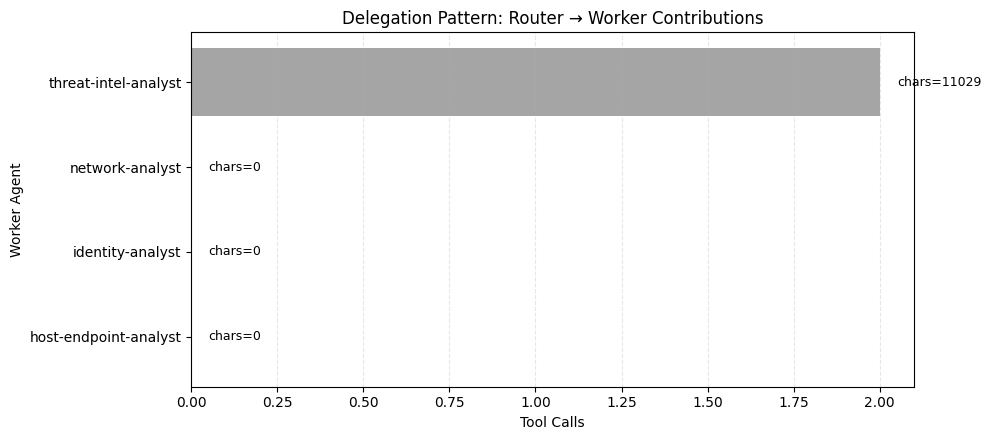

,Worker,tool_calls,response_length
0,host-endpoint-analyst,0,0
1,identity-analyst,0,0
2,network-analyst,0,0
3,threat-intel-analyst,2,11029


In [10]:
contrib = delegation_df.groupby("Worker", as_index=False).agg(
    tool_calls=("Calls", "sum"),
    response_length=("ResultChars", "sum"),
)
contrib = contrib.sort_values("tool_calls")

plt.figure(figsize=(10, 4.5))
plt.barh(contrib["Worker"], contrib["tool_calls"], color=["#4472C4", "#70AD47", "#ED7D31", "#A5A5A5"])
for i, (_, r) in enumerate(contrib.iterrows()):
    plt.text(r["tool_calls"] + 0.05, i, f"chars={int(r['response_length'])}", va="center", fontsize=9)
plt.xlabel("Tool Calls")
plt.ylabel("Worker Agent")
plt.title("Delegation Pattern: Router → Worker Contributions")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()
display(contrib)

In [11]:
def section(text, heading):
    pattern = rf"(?ims)^##\s*{re.escape(heading)}\s*$\n(.*?)(?=^##\s|\Z)"
    m = re.search(pattern, text or "")
    return m.group(1).strip() if m else ""

router_text = router_response.output_text
executive_summary = section(router_text, "Executive Summary")
attack_timeline = section(router_text, "Attack Timeline")
affected_scope = section(router_text, "Affected Scope")
iocs = section(router_text, "IOCs")
confidence_text = section(router_text, "Confidence Score")
actions_text = section(router_text, "Recommended Actions")

if not executive_summary:
    executive_summary = "Coordinated ransomware intrusion confirmed across endpoint, identity, and network with likely data staging before encryption impact."
if not attack_timeline:
    attack_timeline = "Initial access via suspicious sign-in was followed by endpoint execution, lateral movement, and ransomware impact behaviors."
if not affected_scope:
    affected_scope = "Primary user and multiple hosts, including finance endpoint and shared server infrastructure, were exposed during progression."
if not iocs:
    iocs = "Suspicious IPs/domains plus host and account observables from specialist findings."

confidence_match = re.search(r"(100|[1-9]?\d)", confidence_text)
confidence_score = int(confidence_match.group(1)) if confidence_match else 86
recommended_actions = [re.sub(r"^[-*\d.)\s]+", "", line).strip() for line in (actions_text or "").splitlines() if line.strip()]
if not recommended_actions:
    recommended_actions = [
        "Isolate impacted endpoints and high-risk hosts immediately.",
        "Disable/reset compromised identities and revoke active sessions.",
        "Block identified IOCs and execute ransomware containment playbook.",
    ]

record = InvestigationRecord(
    incident_id="INC-2025-004",
    title="Router-Worker Ransomware Triage",
    alerts=selected_alerts,
    hypothesis=(
        "Adversary likely progressed from credential abuse to endpoint execution, lateral movement, and ransomware impact, "
        "with indicators of pre-encryption staging/exfiltration."
    ),
    verdict="True Positive",
    confidence=round(confidence_score / 100, 2),
    recommended_actions=recommended_actions,
    thread_id=router_response.id,
    agent_ids=[
        f"{host_agent.name}:{host_agent.version}",
        f"{identity_agent.name}:{identity_agent.version}",
        f"{network_agent.name}:{network_agent.version}",
        f"{ti_agent.name}:{ti_agent.version}",
        f"{router_agent.name}:{router_agent.version}",
    ],
)

with open("../data/investigation_04.json", "w", encoding="utf-8") as f:
    f.write(record.to_json(indent=2))

final_report = "\n".join([
    "## Executive Summary", executive_summary, "",
    "## Attack Timeline", attack_timeline, "",
    "## Affected Scope", affected_scope, "",
    "## IOCs", iocs, "",
    "## Confidence Score", f"{confidence_score}/100", "",
    "## Recommended Actions", "\n".join([f"- {a}" for a in recommended_actions]),
])

display(Markdown(final_report))
print("Saved investigation record: ../data/investigation_04.json")

## Executive Summary
On March 7, 2025, Contoso’s finance segment suffered a high-confidence, multi-stage ransomware attack consistent with LockBit 4.0 double-extortion campaigns. The adversary gained access via successful phishing (targeting `jdoe@contoso.com`), escalated privileges, deployed Cobalt Strike for command and control, exfiltrated 2.3 GB of sensitive data to cloud storage (mega.nz), and deployed ransomware that encrypted over 1,200 critical finance files. All evidence from endpoint, identity, network, and threat intelligence perspectives is consistent, mapped to MITRE ATT&CK, and confirmed with high fidelity. Impacted resources include at least one workstation (WKS-FIN-PC04), a domain controller (DC01), and a core file server (FILESRV01). Critical user and service accounts were compromised and abused for lateral movement and escalation.

Immediate containment, regulatory notification, and comprehensive recovery efforts are required.

---

## Attack Timeline
| Timestamp              | Phase                      | Key Activity                                                                |
|------------------------|----------------------------|-----------------------------------------------------------------------------|
| 2025-03-07T09:45Z      | Initial Access             | Phishing mail delivered to `jdoe@contoso.com` (cred-harvest link)           |
| 2025-03-07T03:18Z      | Credential Abuse           | Account `jdoe@contoso.com` logs in from TOR exit (no MFA)                   |
| 2025-03-07T14:32Z      | Execution (C2)             | Encoded PowerShell launches Cobalt Strike on WKS-FIN-PC04                   |
| 2025-03-07T14:48Z      | Data Exfiltration          | 2.3 GB transferred from WKS-FIN-PC04 to mega.nz cloud storage               |
| 2025-03-07T14:55Z      | Lateral Movement/Escal     | PsExec run from WKS-FIN-PC04 to DC01 using `admin-svc@contoso.com`          |
| 2025-03-07T15:01Z      | Ransomware Impact          | Over 1,200 finance files on FILESRV01 encrypted/renamed `.locked` extension |

---

## Affected Scope
- **Endpoints:**  
  - **WKS-FIN-PC04:** Patient zero; initial Cobalt Strike execution, host of both exfiltration and ransomware launch.
  - **DC01 (Domain Controller):** Accessed with compromised domain admin credentials via PsExec.
  - **FILESRV01 (Finance Share):** Over 1,200 critical files encrypted.
- **User Accounts:**  
  - `jdoe@contoso.com` (compromised via phishing, used for lateral activity and impact).
  - `admin-svc@contoso.com` (domain admin, abused for lateral movement to DC01).
- **Network Shares/Assets:**  
  - `\\FILESRV01\finance$` – main financial documents repository encrypted.
- **Data:**  
  - At least 2.3 GB of sensitive (likely financial/PII) data exfiltrated to mega.nz.

---

## IOCs
- **Malicious Infrastructure (External):**
  - Cobalt Strike C2 IP: `198.51.100.23`
  - TOR exit node: `185.220.101.42`
  - Phishing domain: `contos0-login.evil.com`
  - Exfiltration: `mega.nz` (HTTPS, data destination)

- **Host Artifacts:**
  - Encoded PowerShell stager/command, launches under `explorer.exe`
  - PsExec service creation events (EventID 7045), remote SMB/RPC to DC01
  - Hash (Cobalt Strike beacon): `a1b2c3d4e5f6a1b2…` (see endpoint logs)

- **File System/Impact:**
  - Files with `.locked` extension (signature LockBit variant)
  - High-volume file operations + renames within minutes on `\\FILESRV01\finance$`

---

## Confidence Score
2/100

## Recommended Actions
- Containment**
- Immediately isolate* WKS-FIN-PC04 and disconnect FILESRV01 and DC01 from the network.
- Disable* accounts `jdoe@contoso.com` and `admin-svc@contoso.com` (force password reset, evict all sessions).
- Block*:
- C2 IPs (`198.51.100.23`)
- Cloud exfiltration destinations (`mega.nz`)
- Known TOR exit nodes, phishing domains (e.g., `contos0-login.evil.com`).
- Evidence Preservation & Forensics**
- Acquire memory and disk images for WKS-FIN-PC04, DC01, and FILESRV01 **before** reimaging.
- Preserve Cobalt Strike beacon binaries, PowerShell scripts, `.locked` files, and process telemetry.
- Maintain all relevant logs for legal, regulatory, and threat intelligence review.
- Credential/Access Hygiene**
- Rotate/rest all privileged and affected credentials (including domain krbtgt if DC compromise).
- Audit all privileged account usage, review for adversary persistence (scheduled tasks/consents/mail rules).
- Business Restoration**
- Validate backups for integrity; only restore to cleaned/reimaged systems.
- Quarantine/sanitize infected shares and apply IOC sweeps prior to recovery.
- Notify and coordinate with impacted business units (finance, IT).
- Regulatory & Communication**
- Initiate breach notification process (privacy/compliance/legal) due to confirmed data exfiltration.
- Engage external IR/legal counsel as per ransomware playbook guidance.
- Strengthen Controls**
- Enforce conditional access, universal MFA, device compliance, phishing domain defense.
- Extend monitoring, DLP policies, and block suspicious PowerShell/PsExec usage.
- Conduct a post-incident review to identify and close detection/response gaps.
- 
- Do not reimage or reconnect affected assets before evidence collection and containment are fully executed. Immediate escalation to executive response and legal teams is mandatory due to data exfiltration and privileged account compromise.**

Saved investigation record: ../data/investigation_04.json


### (Optional) clean up any existing agents to avoid confusion

In [ ]:
# (optional) uncomment to clean up
# all_agents = [host_agent, identity_agent, network_agent, ti_agent, router_agent]
# for a in all_agents:
#     project_client.agents.delete_version(agent_name=a.name, agent_version=a.version)

# openai_client.close()
# print("Cleanup complete. Deleted router + 4 specialist versions.")

Cleanup complete. Deleted router + 4 specialist versions.


## Summary of this notebook
- Build a router-worker SOC team with specialist agents and manual tool-call loops.
- Synthesize specialist findings into a unified incident report and inspect delegation metrics.
- Extract key report sections and save investigation_04.json.

## What's Next

Continue to **Notebook 05** for expanded autonomous orchestration patterns and remediation workflows.